In [7]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt
import math
import json
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)

from ultralytics import YOLO
from utils import *

In [8]:
model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
model = YOLO(os.path.join(model_path, "yolov8n.pt"))

In [9]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
vid_name =  'synth_train'

True


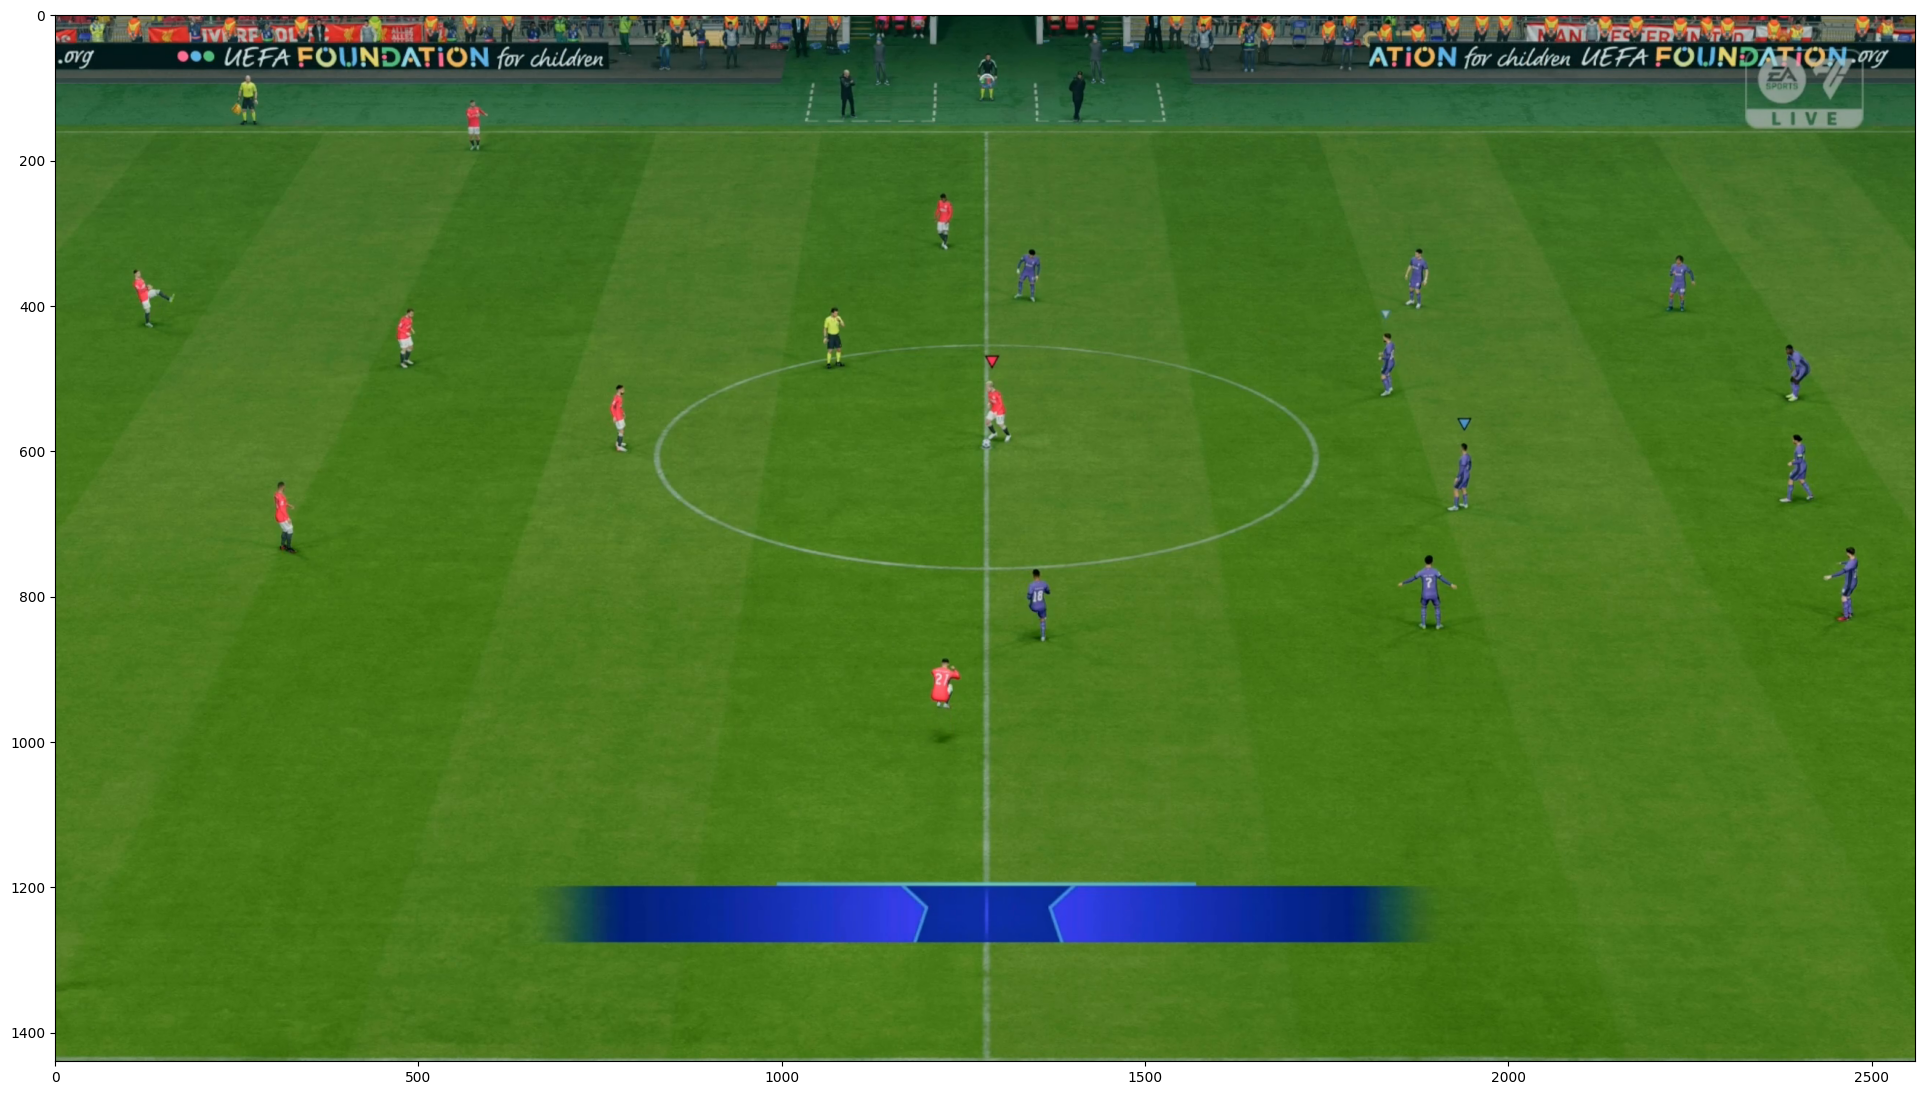

In [10]:
images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
images_path
image_path = os.path.join(images_path, os.listdir(images_path)[1])

rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(rgb_image[:,:,::-1])


0: 384x640 18 persons, 5.1ms
Speed: 1.7ms preprocess, 5.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


0.0
Object type: tensor([0.], device='cuda:0')
[1333, 759, 1371, 867]
0.0
Object type: tensor([0.], device='cuda:0')
[1053, 401, 1090, 489]
0.0
Object type: tensor([0.], device='cuda:0')
[1867, 739, 1918, 850]
0.0
Object type: tensor([0.], device='cuda:0')
[298, 647, 333, 743]
0.0
Object type: tensor([0.], device='cuda:0')
[1320, 319, 1358, 398]
0.0
Object type: tensor([0.], device='cuda:0')
[2376, 575, 2421, 676]
0.0
Object type: tensor([0.], device='cuda:0')
[2448, 732, 2484, 837]
0.0
Object type: tensor([0.], device='cuda:0')
[2217, 332, 2253, 411]
0.0
Object type: tensor([0.], device='cuda:0')
[1918, 564, 1954, 686]
0.0
Object type: tensor([0.], device='cuda:0')
[1818, 421, 1853, 529]
0.0
Object type: tensor([0.], device='cuda:0')
[466, 407, 501, 488]
0.0
Object type: tensor([0.], device='cuda:0')
[106, 353, 137, 427]
0.0
Object type: tensor([0.], device='cuda:0')
[760, 511, 790, 600]
0.0
Object type: tensor([0.], device='cuda:0')
[1207, 244, 1240, 327]
0.0
Object type: tensor([0.]

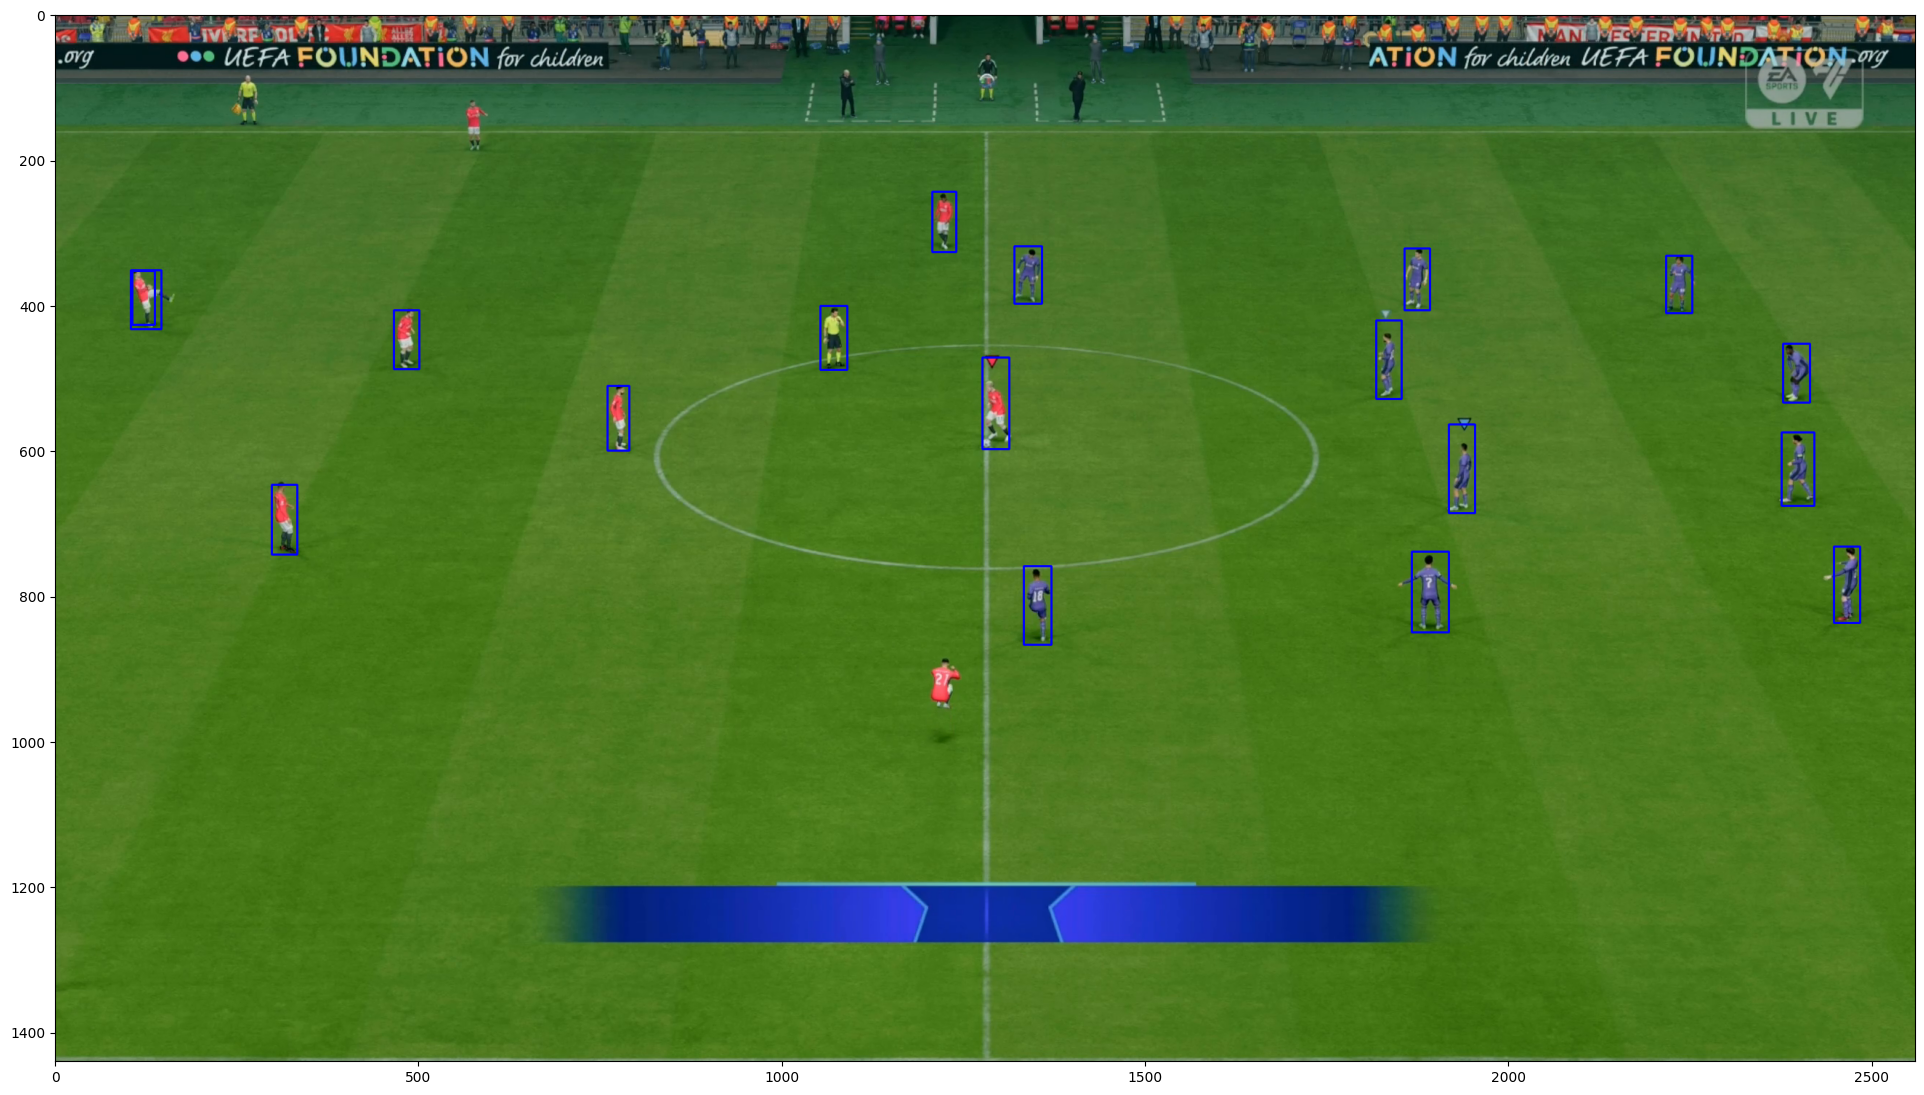

In [11]:
results = model.predict(rgb_image)

for result in results:
    boxes = result.boxes
    for box in boxes:
        coord = box.xyxy.cpu().detach().int().tolist()[0]
        class_id = box.cls[0].item()
        print(class_id)
        print("Object type:", box.cls)
        
        print(coord)
        (startX, startY, endX, endY) = coord
        cv2.rectangle(rgb_image, (startX, startY), (endX, endY),
    				(255, 0, 0), 2)
        
        
        
plt.figure()
plt.imshow(rgb_image[:,:,::-1])


In [12]:
dest_path = os.path.join(data_path, 'annotated_frames' + '/' + vid_name)
if not os.path.exists(dest_path):
    os.mkdir(dest_path)


visualize_path = os.path.join(dest_path, "annotated_frames")
if not os.path.exists(visualize_path):
    os.mkdir(visualize_path)

for image_name in os.listdir(images_path):
    frame = os.path.join(images_path, image_name)

    # Run YOLOv8 inference on the frame
    results = model(frame, classes=[0, 32])

    # Visualize the results on the frame
    annotated_frame = results[0].plot()

    # Display the annotated frame
    cv2.imwrite(os.path.join(visualize_path, image_name), annotated_frame)

ref_image = cv2.imread(os.path.join(visualize_path, os.listdir(visualize_path)[0]), cv2.IMREAD_UNCHANGED)
h, w, _ = ref_image.shape
video= cv2.VideoWriter(os.path.join(visualize_path, vid_name+'.mp4'), cv2.VideoWriter_fourcc(*'mp4v'), 3, (w,h))
for image_name in os.listdir(visualize_path):
    frame = cv2.imread(os.path.join(visualize_path, image_name), cv2.IMREAD_UNCHANGED)
    video.write(frame)
video.release()




image 1/1 /media/khoa-ys/Personal/Projects/Football Analysis/Football-analysis/data/images/synth_train/000000000005.png: 384x640 18 persons, 3.0ms
Speed: 1.4ms preprocess, 3.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /media/khoa-ys/Personal/Projects/Football Analysis/Football-analysis/data/images/synth_train/000000000006.png: 384x640 18 persons, 3.4ms
Speed: 1.4ms preprocess, 3.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /media/khoa-ys/Personal/Projects/Football Analysis/Football-analysis/data/images/synth_train/000000000009.png: 384x640 17 persons, 1 sports ball, 3.3ms
Speed: 1.4ms preprocess, 3.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /media/khoa-ys/Personal/Projects/Football Analysis/Football-analysis/data/images/synth_train/000000000019.png: 384x640 25 persons, 3.0ms
Speed: 1.7ms preprocess, 3.0ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/

In [13]:
export_coco_dataset_from_prediction(data_path, vid_name, model_name="yolov8n.pt")


image 1/1 /media/khoa-ys/Personal/Projects/Football Analysis/Football-analysis/data/images/synth_train/000000000005.png: 384x640 18 persons, 4.0ms
Speed: 1.4ms preprocess, 4.0ms inference, 0.9ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /media/khoa-ys/Personal/Projects/Football Analysis/Football-analysis/data/images/synth_train/000000000006.png: 384x640 18 persons, 3.4ms
Speed: 1.4ms preprocess, 3.4ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /media/khoa-ys/Personal/Projects/Football Analysis/Football-analysis/data/images/synth_train/000000000009.png: 384x640 17 persons, 1 sports ball, 3.1ms
Speed: 1.4ms preprocess, 3.1ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 /media/khoa-ys/Personal/Projects/Football Analysis/Football-analysis/data/images/synth_train/000000000019.png: 384x640 25 persons, 3.2ms
Speed: 1.4ms preprocess, 3.2ms inference, 0.8ms postprocess per image at shape (1, 3, 384, 640)

image 1/